## Task 6: House Price Prediction

### 🎯 Objective
Predict house prices using features like size, bedrooms, bathrooms, and location.

### 📊 Dataset
House Price Prediction Dataset (Kaggle)

### 📌 Instructions
Load and inspect data
Preprocess data (handle missing values, encode categories)
Train regression model (XGBoost)
Visualize predicted vs actual prices
Evaluate using MAE, RMSE, and R² Score

### 📈 Skills
Regression modeling
Data preprocessing
Model evaluation (MAE, RMSE, R²)

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [129]:
df = pd.read_csv("zameen-updated.csv")
df

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,17355248,6754,https://www.zameen.com/Property/gulshan_e_maym...,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,9.6 Marla,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla
168442,17355249,680,https://www.zameen.com/Property/gadap_town_gul...,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,8 Marla,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,8.0,5-10 Marla
168443,17355250,6757,https://www.zameen.com/Property/gulshan_e_maym...,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,9.6 Marla,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla
168444,17355251,6752,https://www.zameen.com/Property/gulshan_e_maym...,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,7.8 Marla,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,7.8,5-10 Marla


In [130]:
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [108]:
#Counting the number of rown containing null values
row_count = df.isnull().any(axis=1).sum()
row_count

np.int64(44072)

In [109]:
#dropping null rows and specific columns

df = df.dropna()
df = df.drop(columns=[
    'property_id',
    'location_id',
    'page_url',
    'agency',
    'agent',
    'area',
    'Area Category',
    'province_name',
    'location',
    "date_added"
])
df

,property_type,price,city,latitude,longitude,baths,purpose,bedrooms,Area Type,Area Size
4,House,7000000,Islamabad,33.492591,73.301339,3,For Sale,3,Marla,8.0
7,Flat,7800000,Islamabad,33.698244,72.984238,2,For Sale,2,Marla,6.2
8,House,50000000,Islamabad,33.540894,73.095732,7,For Sale,7,Kanal,1.0
9,Penthouse,40000000,Islamabad,33.679211,72.988787,5,For Sale,5,Kanal,1.0
10,Flat,35000000,Islamabad,33.728873,73.119628,3,For Sale,3,Marla,7.1
...,...,...,...,...,...,...,...,...,...,...
168441,House,26500000,Karachi,25.029909,67.137192,0,For Sale,6,Marla,9.6
168442,House,12500000,Karachi,25.017951,67.136393,0,For Sale,3,Marla,8.0
168443,House,27000000,Karachi,25.015384,67.116330,0,For Sale,6,Marla,9.6
168444,House,11000000,Karachi,25.013265,67.120818,0,For Sale,3,Marla,7.8


In [110]:
df[df["purpose"] == "For Sale"].shape[0]

89191

In [111]:
#Keeping only those rows that are for sale.
df = df[df["purpose"] == "For Sale"]

In [112]:
df = df.drop("purpose", axis=1)
df

,property_type,price,city,latitude,longitude,baths,bedrooms,Area Type,Area Size
4,House,7000000,Islamabad,33.492591,73.301339,3,3,Marla,8.0
7,Flat,7800000,Islamabad,33.698244,72.984238,2,2,Marla,6.2
8,House,50000000,Islamabad,33.540894,73.095732,7,7,Kanal,1.0
9,Penthouse,40000000,Islamabad,33.679211,72.988787,5,5,Kanal,1.0
10,Flat,35000000,Islamabad,33.728873,73.119628,3,3,Marla,7.1
...,...,...,...,...,...,...,...,...,...
168441,House,26500000,Karachi,25.029909,67.137192,0,6,Marla,9.6
168442,House,12500000,Karachi,25.017951,67.136393,0,3,Marla,8.0
168443,House,27000000,Karachi,25.015384,67.116330,0,6,Marla,9.6
168444,House,11000000,Karachi,25.013265,67.120818,0,3,Marla,7.8


In [114]:
#Making a new column "area_marla" by changing the kanal to marla

def convert_area(row):
    if row["Area Type"] == "Kanal":
        return row["Area Size"] * 20
    return row["Area Size"]

df["area_marla"] = df.apply(convert_area, axis=1)

#Performing one-Hot encoding on the categorical columns
df = pd.get_dummies(
    df,
    columns=["property_type", "city"],
    drop_first=True
)

df


,price,latitude,longitude,baths,bedrooms,Area Type,Area Size,area_marla,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi
4,7000000,33.492591,73.301339,3,3,Marla,8.0,8.0,False,True,False,False,False,False,True,False,False,False
7,7800000,33.698244,72.984238,2,2,Marla,6.2,6.2,True,False,False,False,False,False,True,False,False,False
8,50000000,33.540894,73.095732,7,7,Kanal,1.0,20.0,False,True,False,False,False,False,True,False,False,False
9,40000000,33.679211,72.988787,5,5,Kanal,1.0,20.0,False,False,False,True,False,False,True,False,False,False
10,35000000,33.728873,73.119628,3,3,Marla,7.1,7.1,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,26500000,25.029909,67.137192,0,6,Marla,9.6,9.6,False,True,False,False,False,False,False,True,False,False
168442,12500000,25.017951,67.136393,0,3,Marla,8.0,8.0,False,True,False,False,False,False,False,True,False,False
168443,27000000,25.015384,67.116330,0,6,Marla,9.6,9.6,False,True,False,False,False,False,False,True,False,False
168444,11000000,25.013265,67.120818,0,3,Marla,7.8,7.8,False,True,False,False,False,False,False,True,False,False


In [115]:
df = df.drop(["Area Type", "Area Size"], axis=1)
df

,price,latitude,longitude,baths,bedrooms,area_marla,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi
4,7000000,33.492591,73.301339,3,3,8.0,False,True,False,False,False,False,True,False,False,False
7,7800000,33.698244,72.984238,2,2,6.2,True,False,False,False,False,False,True,False,False,False
8,50000000,33.540894,73.095732,7,7,20.0,False,True,False,False,False,False,True,False,False,False
9,40000000,33.679211,72.988787,5,5,20.0,False,False,False,True,False,False,True,False,False,False
10,35000000,33.728873,73.119628,3,3,7.1,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,26500000,25.029909,67.137192,0,6,9.6,False,True,False,False,False,False,False,True,False,False
168442,12500000,25.017951,67.136393,0,3,8.0,False,True,False,False,False,False,False,True,False,False
168443,27000000,25.015384,67.116330,0,6,9.6,False,True,False,False,False,False,False,True,False,False
168444,11000000,25.013265,67.120818,0,3,7.8,False,True,False,False,False,False,False,True,False,False


In [116]:
#Changing the boolean data type columns into integer datatype
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [117]:
df

,price,latitude,longitude,baths,bedrooms,area_marla,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi
4,7000000,33.492591,73.301339,3,3,8.0,0,1,0,0,0,0,1,0,0,0
7,7800000,33.698244,72.984238,2,2,6.2,1,0,0,0,0,0,1,0,0,0
8,50000000,33.540894,73.095732,7,7,20.0,0,1,0,0,0,0,1,0,0,0
9,40000000,33.679211,72.988787,5,5,20.0,0,0,0,1,0,0,1,0,0,0
10,35000000,33.728873,73.119628,3,3,7.1,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,26500000,25.029909,67.137192,0,6,9.6,0,1,0,0,0,0,0,1,0,0
168442,12500000,25.017951,67.136393,0,3,8.0,0,1,0,0,0,0,0,1,0,0
168443,27000000,25.015384,67.116330,0,6,9.6,0,1,0,0,0,0,0,1,0,0
168444,11000000,25.013265,67.120818,0,3,7.8,0,1,0,0,0,0,0,1,0,0


In [118]:
#Removing the outliers from the df.
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]
df

,price,latitude,longitude,baths,bedrooms,area_marla,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi
4,7000000,33.492591,73.301339,3,3,8.0,0,1,0,0,0,0,1,0,0,0
7,7800000,33.698244,72.984238,2,2,6.2,1,0,0,0,0,0,1,0,0,0
8,50000000,33.540894,73.095732,7,7,20.0,0,1,0,0,0,0,1,0,0,0
9,40000000,33.679211,72.988787,5,5,20.0,0,0,0,1,0,0,1,0,0,0
10,35000000,33.728873,73.119628,3,3,7.1,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,26500000,25.029909,67.137192,0,6,9.6,0,1,0,0,0,0,0,1,0,0
168442,12500000,25.017951,67.136393,0,3,8.0,0,1,0,0,0,0,0,1,0,0
168443,27000000,25.015384,67.116330,0,6,9.6,0,1,0,0,0,0,0,1,0,0
168444,11000000,25.013265,67.120818,0,3,7.8,0,1,0,0,0,0,0,1,0,0


In [119]:
#Converting the target variable "price" to make distributions normal.
df = df.copy()
df["price"] = np.log1p(df["price"].astype(float))

<Axes: >

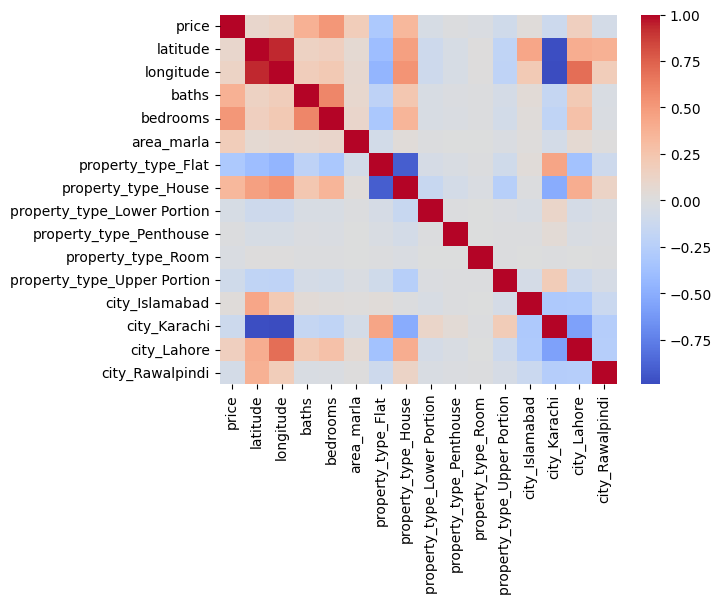

In [120]:
# Correlation Heatmap
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")

In [121]:
df

,price,latitude,longitude,baths,bedrooms,area_marla,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi
4,15.761421,33.492591,73.301339,3,3,8.0,0,1,0,0,0,0,1,0,0,0
7,15.869634,33.698244,72.984238,2,2,6.2,1,0,0,0,0,0,1,0,0,0
8,17.727534,33.540894,73.095732,7,7,20.0,0,1,0,0,0,0,1,0,0,0
9,17.504390,33.679211,72.988787,5,5,20.0,0,0,0,1,0,0,1,0,0,0
10,17.370859,33.728873,73.119628,3,3,7.1,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,17.092655,25.029909,67.137192,0,6,9.6,0,1,0,0,0,0,0,1,0,0
168442,16.341239,25.017951,67.136393,0,3,8.0,0,1,0,0,0,0,0,1,0,0
168443,17.111347,25.015384,67.116330,0,6,9.6,0,1,0,0,0,0,0,1,0,0
168444,16.213406,25.013265,67.120818,0,3,7.8,0,1,0,0,0,0,0,1,0,0


In [122]:
X = df.drop("price", axis=1)
y = df["price"]

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [124]:
#Initialize model
n_estimators = 100
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

In [125]:
#Training the Model
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [126]:
#Measuring the MSE, R2, MAE and RMSE on logged target values
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(f'      XGBoost:  MSE = {mse_xgb:.4f}, R^2 = {r2_xgb:.4f}, MAE = {mae_xgb:.4f}, RMSE = {rmse_xgb:.4f}')

#Measuring the MSE, R2, MAE and RMSE on original target values

#Converting the predicted and  test values back to their origingal format
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_xgb)

mse_xgb = mean_squared_error(y_test_real, y_pred_real)
r2_xgb = r2_score(y_test_real, y_pred_real)
mae_xgb = mean_absolute_error(y_test_real, y_pred_real)
rmse_xgb = np.sqrt(mse_xgb)

print(f'      XGBoost:  MSE = {mse_xgb:.4f}, R^2 = {r2_xgb:.4f}, MAE = {mae_xgb:.4f}, RMSE = {rmse_xgb:.4f}')

      XGBoost:  MSE = 0.0981, R^2 = 0.8569, MAE = 0.1609, RMSE = 0.3132
      XGBoost:  MSE = 17719280125434.1289, R^2 = 0.8952, MAE = 2471098.3399, RMSE = 4209427.5294


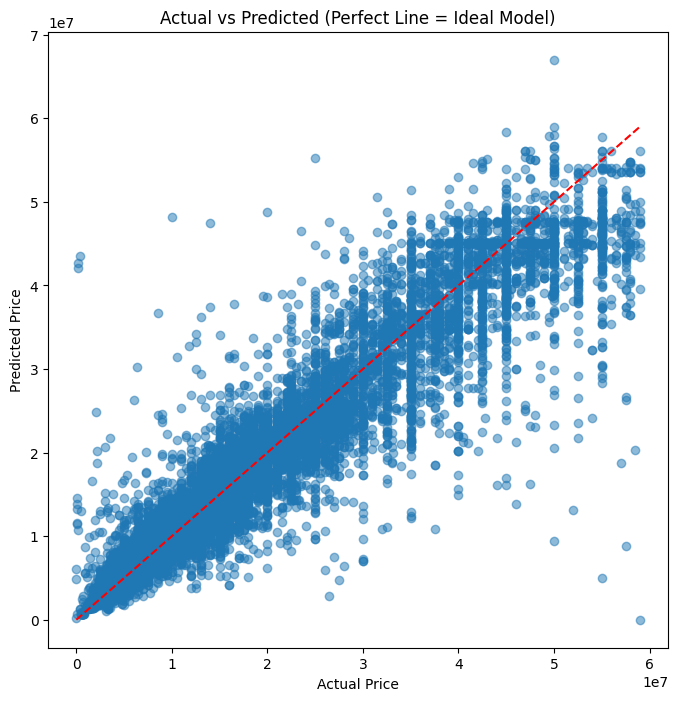

In [127]:
plt.figure(figsize=(8,8))

plt.scatter(y_test_real, y_pred_real, alpha=0.5)

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Perfect Line = Ideal Model)")
plt.show()

### Explanation and Final Insights
The model is using the zameen.com data. At starting all the redundant columns have been removed. After performing preprocessing on the data the model has been trained and gave fairly good prices of MSE = 0.0981, R^2 = 0.8569, MAE = 0.1609, RMSE = 0.3132. This suggests that model is performing 70%-85% accurately and the last scatter plot that has been drawn proves that. As most of the dots lies above and below the perfect red line.